In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized_sinbeta_sparse import TVqRegularized
from bimpcc.models.tvq_denoising_sinbeta import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')
    
    plt.show()
    return psnr(true,noisy),psnr(true,u)

In [4]:
scale = 128

In [5]:
dataset = get_dataset("guacamayo",scale=scale, random_state=1)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

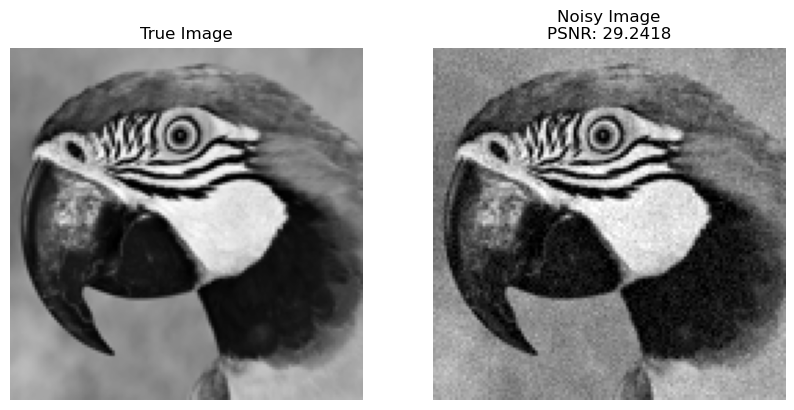

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [7]:
model = TVqRegularized(true, noisy, epsilon=1e-3, q_param=0.99)

In [8]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

[100.]
[100.]
[100.]
[99.55913781]
[93.36992687]
[91.49910211]
[91.07424202]
[90.57996247]
[78.40188504]
[77.34178199]
[68.22849405]
[66.80619547]
[58.79256342]
[60.69972429]
[60.54385634]
[60.51196861]
[60.46404054]
[60.46816979]
[60.47310813]
[60.47866368]
[60.47822101]
[60.49137119]
[60.48572739]
[60.48373038]
[60.48379661]


In [9]:
print(open("ipopt.log", "r", encoding="utf-8", errors="ignore").read()[:5000])


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:   835388
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:    48897
                     variables with only lower bounds:    16385
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    48896
Total number of inequality c

In [10]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

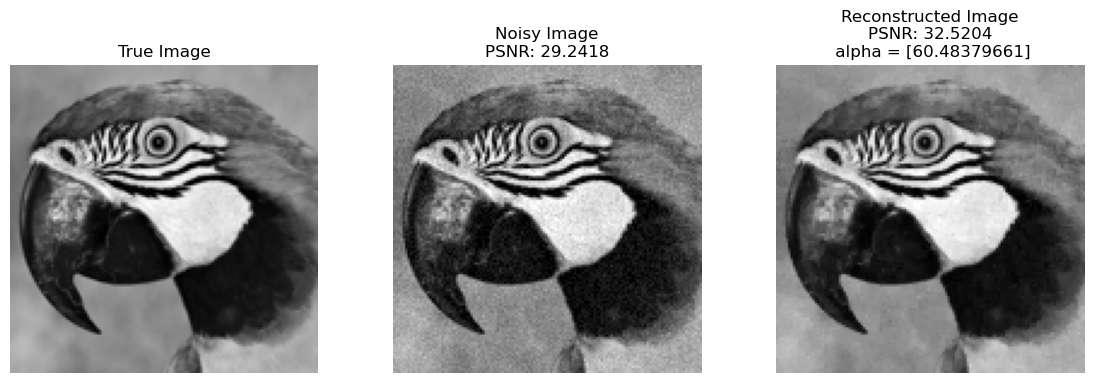

In [11]:
u_scaled = u.reshape((scale,scale))
psnr_n, psrn_r = plot_experiment(true,noisy,u_scaled,alpha)

In [12]:
# x0_q = None
# #vect_q = [0.99, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5]
# vect_q = [0.99, 0.9]
# for i in range(len(vect_q)):
#     model = TVqRegularized(true, noisy, epsilon = 1e-3, x0 = x0_q, q_param = vect_q[i])
#     res,x_opt,fun_opt = model.solve(max_iter = 3000,tol = 1e-4,print_level = 5)
#     u, q, alpha = model.objective_func.parse_vars(x_opt)
#     x0_q = np.concatenate((u, q, alpha))

# u_scaled = u.reshape((scale,scale))
# plot_experiment(true,noisy,u_scaled,alpha)
    

In [13]:
Kx, Ky, K = generate_2D_gradient_matrices(scale)

In [14]:
m = q.flatten().size
n = m // 2

Ku = K @ u.flatten()
V = Ku.reshape(2, -1).T
normKu = np.apply_along_axis(np.linalg.norm, axis=1, arr=V)
Q = q.reshape(2,-1).T
normQ = np.apply_along_axis(np.linalg.norm, axis=1, arr=Q)
r0 = normKu
delta0 = normQ

In [15]:
Kxu = Ku[:n]  # Primeras n componentes
Kyu = Ku[n:]  # Últimas n componentes
qx = q[:n]  # Primeras n componentes
qy = q[n:]  # Últimas n componentes
epsilon = 1e-10  

# Condiciones para calcular theta según los casos dados
theta0 = np.zeros(n)  # Inicializamos theta0

# Caso 1: r_i ≠ 0
mask_r_nonzero = r0 > epsilon
theta0[mask_r_nonzero] = np.arccos(Kxu[mask_r_nonzero] / r0[mask_r_nonzero])
theta0[mask_r_nonzero & (Kyu < 0)] *= -1  # Si Ky^i u < 0, negamos theta0

# Caso 2: r_i = 0 y delta_i ≠ 0
mask_r_zero_delta_nonzero = (r0 <= epsilon) & (delta0 > epsilon)
theta0[mask_r_zero_delta_nonzero] = np.arccos(qx[mask_r_zero_delta_nonzero] / delta0[mask_r_zero_delta_nonzero])
theta0[mask_r_zero_delta_nonzero & (qy < 0)] *= -1  # Si qy^i < 0, negamos theta0

# Caso 3: r_i = 0 y delta_i = 0 (theta0 indefinido)
mask_r_zero_delta_zero = (r0 <= epsilon) & (delta0 <= epsilon)
theta0[mask_r_zero_delta_zero] = 0

In [16]:
x0_mpcc = np.concatenate((u.flatten(),q.flatten(),r0,delta0,theta0,alpha))
# print(x0_mpcc)

In [17]:
mpcc_model = TVDenoisingMPCC(true, noisy, x0=x0_mpcc, epsilon=1e-3, q_param = 0.99)

In [18]:
res_mpcc, x_opt_mpcc, fun_opt_mpcc, history = mpcc_model.solve(t_init = 0.0001, t_min = 1e-8, max_iter=100,tol=1e-5,print_level=5,verbose=True)

Iter   Termination_status            Objective      MPCC_compl               t

0                 0  4.575153020800129       0.30508972914628596             0.0001

1                 0  4.581581254208791       0.19710275362415824              5e-05

2                 0  4.585179184606023       0.12385971552079728            2.5e-05

3                 0  4.587170656941229       0.07790199122675778           1.25e-05

...

13                 0  4.589530333975406       0.0007152110459265288   1.220703125e-08

Intermediate result: {'x': array([ 0.55820202,  0.56003474,  0.55859151, ...,  2.76307711,
        1.50889271, 59.47089029], shape=(97665,)), 'fun': 4.589530333975406, 'info': {'x': array([ 0.55820202,  
0.56003474,  0.55859151, ...,  2.76307711,
        1.50889271, 59.47089029], shape=(97665,)), 'g': array([-2.08721929e-14, -1.70336634e-10,  2.70271583e-11, 
...,
        1.81165410e-09,  7.12460356e-10,  1.33232936e-09], shape=(113920,)), 'obj_val': 4.589530333975406, 
'mult_g': array([ 5.78209480e-06, -1.08482951e-05,  4.55027937e-05, ...,
       -5.57480219e-02, -6.14682650e-02, -5.81060020e-02], shape=(113920,)), 'mult_x_L': array([1.17963804e-09, 
1.17577767e-09, 1.17881553e-09, ...,
       0.00000000e+00, 0.00000000e+00, 1.10722464e-11], shape=(97665,)), 'mult_x_U': array([0., 0., 0., ..., 0., 
0., 0.], shape=(97665,)), 'status': 0, 'status_msg': b'Algorithm terminated successfully at a locally optimal 
point, satisfying the convergence tolerances (can be specified by options).'}, 'status': 0}

Intermediate fn: 4.589530333975406

complementarity: 0.0007152110459265288

* (STOPPED) Iteration 15: Solving the NLP problem for t = 1e-08 with complementarity: 0.0007152110459265288

In [19]:
print(open("ipopt_mpcc.log", "r", encoding="utf-8", errors="ignore").read()[:5000])

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:   965436
Number of nonzeros in inequality constraint Jacobian.:    48768
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:    97665
                     variables with only lower bounds:    48897
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    81408
Total number of inequality constraints...............:    32512
        inequality constraints with only lower bounds:    32512
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  4.5895262e+00 4.60e-02 3.73e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [20]:
u_mpcc, q_mpcc, r_mpcc, delta_mpcc, theta_mpcc, alpha_mpcc = mpcc_model.objective_func.parse_vars(x_opt_mpcc)

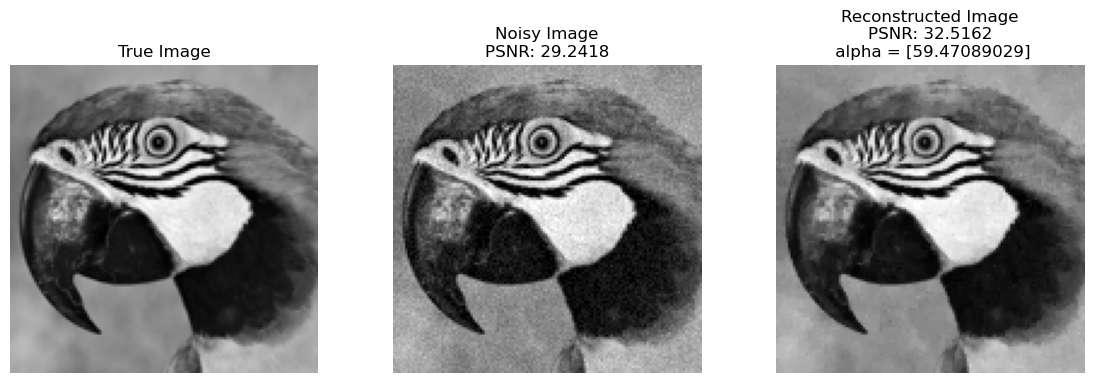

In [21]:
u_mpcc_scaled = u_mpcc.reshape((scale,scale))
psnr_n_mpcc, psnr_r_mpcc = plot_experiment(true,noisy,u_mpcc_scaled,alpha_mpcc)

In [22]:
def history_to_latex(
    history,
    experiment_name="tabla_mpcc",
):
    def fmt(x):
        if x is None:
            return "-"
        if isinstance(x, int):
            return f"{x}"
        x = float(x)
        # Formato decimal fijo, sin notación científica
        s = f"{x:.8f}"          # ajusta decimales si quieres
        s = s.rstrip('0').rstrip('.')  # limpia ceros finales
        return s

    lines = []
    lines.append("\\begin{tabular}{c c c c c c}")
    lines.append("\\toprule")
    lines.append("Iter & Compl & NLP iter & Fun Obj & $t$ & $\\alpha$ \\\\")
    lines.append("\\midrule")

    for row in history:
        lines.append(
            f"{fmt(row['k'])} & "
            f"{fmt(row['comp'])} & "
            f"{fmt(row['nlp_iter'])} & "
            f"{fmt(row['obj'])} & "
            f"{fmt(row['t'])} & "
            f"{fmt(row['alpha'])} \\\\"
        )

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")

    latex_table = "\n".join(lines)

    # -----------------------------
    # Crear carpeta y guardar
    # -----------------------------
    results_dir = "results_table"
    os.makedirs(results_dir, exist_ok=True)

    table_path = os.path.join(results_dir, f"{experiment_name}.tex")
    with open(table_path, "w", encoding="utf-8") as f:
        f.write(latex_table)

    print(f"Tabla LaTeX guardada en: {table_path}")

    return 

In [23]:
history_to_latex(
    history,
    experiment_name=(f"tabla_mpcc_0.99_guacamayo_{scale}"),
)

Tabla LaTeX guardada en: results_table\tabla_mpcc_0.99_guacamayo_128.tex


In [24]:
from pathlib import Path
from imageio import imwrite

In [25]:
#### GUARDAMOS IMÁGENES 
out_dir = Path("results_tvq") / "guacamayo_mpcc"   # <- dos carpetas
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"true_guacamyo_{scale}.png"
imwrite(str(out_path), (true * 255).astype(np.uint8))

In [26]:
out_path = out_dir / f"noisy_guacamayo_{scale}_{psnr_n_mpcc:.4f}.png"
imwrite(str(out_path), (noisy * 255).astype(np.uint8))

In [27]:
out_path = out_dir / f"recons_guacamayo_{scale}_{psnr_r_mpcc:.4f}_{alpha_mpcc[0]:.4f}.png"
imwrite(str(out_path), (u_mpcc_scaled * 255).astype(np.uint8))